In [3]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from supabase import create_client

%matplotlib inline

project_root = Path.cwd().parent
env_path = project_root / ".env"

load_dotenv(dotenv_path=env_path, override=True)

SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

supabase = create_client(SUPABASE_URL, SUPABASE_KEY)


In [4]:
page_size = 1000
all_rows = []
start = 0

while True:
    response = (
        supabase
        .table("incident")
        .select("*")
        .order("Incident_ID")
        .range(start, start + page_size - 1)
        .execute()
    )

    data = response.data
    if not data:
        break

    all_rows.extend(data)
    start += page_size

incident_df = pd.DataFrame(all_rows)
incident_df["Number_Victims"] = pd.to_numeric(incident_df["Number_Victims"], errors="coerce")


In [5]:
page_size = 1000
all_rows = []
start = 0

while True:
    response = (
        supabase
        .table("shooter")
        .select("*")
        .order("Incident_ID")
        .range(start, start + page_size - 1)
        .execute()
    )

    data = response.data
    if not data:
        break

    all_rows.extend(data)
    start += page_size

shooter_df = pd.DataFrame(all_rows)


In [6]:
page_size = 1000
all_rows = []
start = 0

while True:
    response = (
        supabase
        .table("victim")
        .select("*")
        .order("Incident_ID")
        .range(start, start + page_size - 1)
        .execute()
    )

    data = response.data
    if not data:
        break

    all_rows.extend(data)
    start += page_size

victim_df = pd.DataFrame(all_rows)


In [7]:
page_size = 1000
all_rows = []
start = 0

while True:
    response = (
        supabase
        .table("weapon")
        .select("*")
        .order("Incident_ID")
        .range(start, start + page_size - 1)
        .execute()
    )

    data = response.data
    if not data:
        break

    all_rows.extend(data)
    start += page_size

weapon_df = pd.DataFrame(all_rows)


In [8]:
response = (
    supabase
    .table("national_enrollment_trend_mv")
    .select("*")
    .execute()
)

national_enrollment_trend_df = pd.DataFrame(response.data)
national_enrollment_trend_df["year"] = pd.to_numeric(national_enrollment_trend_df["year"], errors="coerce")
national_enrollment_trend_df["national_enrollment"] = pd.to_numeric(national_enrollment_trend_df["national_enrollment"], errors="coerce")
national_enrollment_trend_df = national_enrollment_trend_df.dropna(subset=["year", "national_enrollment"]).sort_values("year")
national_enrollment_trend_df["year"] = national_enrollment_trend_df["year"].astype(int)


In [9]:
response = (
    supabase
    .table("incident_rate_per_100k")
    .select("*")
    .order("year")
    .execute()
)

df = pd.DataFrame(response.data)
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["incident_count"] = pd.to_numeric(df["incident_count"], errors="coerce")
df["national_enrollment"] = pd.to_numeric(df["national_enrollment"], errors="coerce")
df["incidents_per_100k_students"] = pd.to_numeric(df["incidents_per_100k_students"], errors="coerce")
df = df.dropna(subset=["year", "incident_count", "national_enrollment"]).sort_values("year")
df["year"] = df["year"].astype(int)
df = df[df["national_enrollment"] > 0].copy()
df["risk_per_100k"] = (df["incident_count"] / df["national_enrollment"]) * 100000


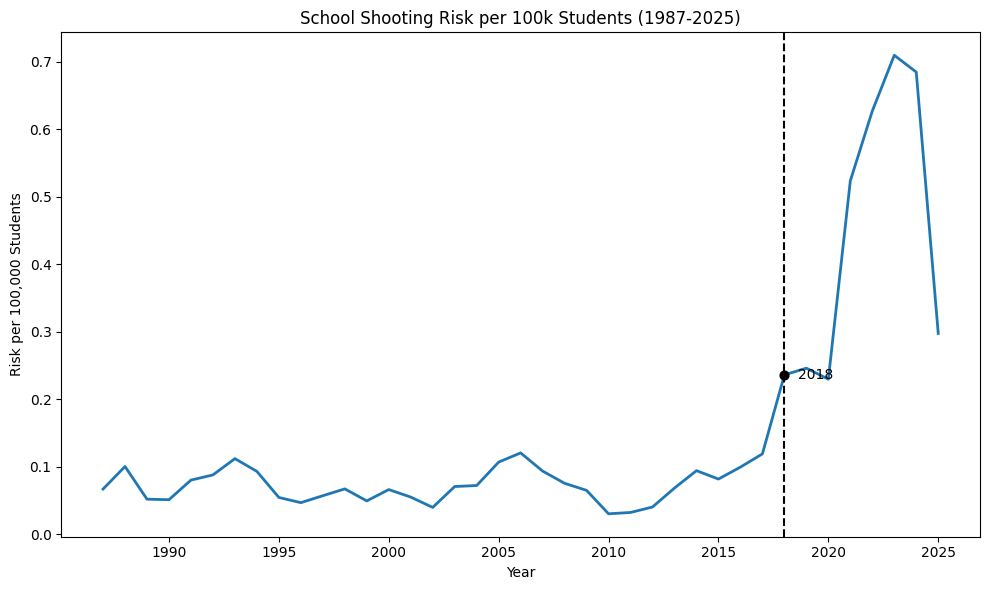

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(df["year"], df["risk_per_100k"], linewidth=2)
plt.axvline(2018, color="black", linestyle="--", linewidth=1.5)

if (df["year"] == 2018).any():
    risk_2018 = df.loc[df["year"] == 2018, "risk_per_100k"].iloc[0]
    plt.scatter([2018], [risk_2018], color="black", s=40, zorder=3)
    plt.annotate("2018", xy=(2018, risk_2018), xytext=(2018.6, risk_2018), va="center")

plt.xlabel("Year")
plt.ylabel("Risk per 100,000 Students")
plt.title("School Shooting Risk per 100k Students (1987-2025)")
plt.tight_layout()
plt.show()
